## Component sum check

Four checks:
1. **Astro + Conv + Muon = Total?** — standard components (nosyst) should sum to `MC_nosyst`
2. **Astro vs Astro_3flavor** — same normalization/composition, different physics model
3. **NuE + NuMu + NuTau = Astro_3flavor?** — flavor components should sum to the 3-flavor total
4. **Gradient issue** — flavor components are stored as nosyst; their sum does NOT equal `MC_syst`. This section reproduces the discrepancy seen in the flavor plots and shows the gradient-corrected sum that should be used instead.

In [15]:
%matplotlib inline
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

from NNMFit.utilities import load_pickle

GRAPH_DIR = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/unblind/step1_hese_flux/graphs/11features_plus_rloglmilli_econf_evtgen"

def load(name):
    return load_pickle(os.path.join(GRAPH_DIR, name))

mc_syst   = load("MC_Histogram.pickle")          # total MC WITH systematics (what the plot shows as total)
total     = load("MC_Histogram_nosyst.pickle")   # total MC without systematics
astro     = load("MC_Histogram_Astro_nosyst.pickle")
conv      = load("MC_Histogram_Conv_nosyst.pickle")
muon      = load("MC_Histogram_Muon_nosyst.pickle")
astro_3f  = load("MC_Histogram_Astro_3flavor_nosyst.pickle")
nue       = load("MC_Histogram_Astro_NuE_nosyst.pickle")
numu      = load("MC_Histogram_Astro_NuMu_nosyst.pickle")
nutau     = load("MC_Histogram_Astro_NuTau_nosyst.pickle")

det_configs = list(total["histograms"].keys())
print("Detector configs:", det_configs)

Detector configs: ['IC86_pass2_SnowStorm_FTP_HESE_Cascades', 'IC86_pass2_SnowStorm_FTP_HESE_DoubleCascades', 'IC86_pass2_SnowStorm_FTP_HESE_Tracks']


In [16]:
def ratio_plot(fig_title, det_configs, top_traces, ratio_traces, ratio_ylabel):
    """Generic helper: top panel = stacked stairs, bottom panel = ratio.
    top_traces:   list of (arr_flat, label, color, linewidth, linestyle)
    ratio_traces: list of (numerator_flat, denominator_flat, label, color)
    """
    ncols = len(det_configs)
    fig, axes = plt.subplots(2, ncols, figsize=(5*ncols, 6),
                              gridspec_kw={"height_ratios": [3, 1]})
    if ncols == 1:
        axes = [[axes[0]], [axes[1]]]

    for col, dc in enumerate(det_configs):
        ax0, ax1 = axes[0][col], axes[1][col]
        n = None
        for arr_full, label, color, lw, ls in top_traces:
            arr = arr_full[dc].ravel()
            n = len(arr)
            bins = np.arange(n + 1)
            ax0.stairs(arr, bins, label=label, color=color, linewidth=lw, linestyle=ls)
        ax0.set_yscale("log")
        ax0.set_ylabel("Count")
        ax0.set_title(dc.split("_")[-1])
        ax0.legend(fontsize=7)

        centers = np.arange(n) + 0.5
        for num_full, den_full, label, color in ratio_traces:
            num = num_full[dc].ravel()
            den = den_full[dc].ravel()
            ratio = np.where(den > 0, num / den, np.nan)
            ax1.plot(centers, ratio, ".", color=color, markersize=3, label=label)
            max_dev = np.nanmax(np.abs(ratio - 1))
            print(f"{dc} | {label}: max |ratio-1| = {max_dev:.2e}")
        ax1.axhline(1, color="grey", linestyle="--", linewidth=0.8)
        ax1.set_ylim(0.85, 1.15)
        ax1.set_ylabel(ratio_ylabel)
        ax1.set_xlabel("Flat bin index")
        if len(ratio_traces) > 1:
            ax1.legend(fontsize=7)

    fig.suptitle(fig_title, fontsize=11)
    plt.tight_layout()
    plt.show()

### 1. Astro + Conv + Muon vs Total (nosyst)

IC86_pass2_SnowStorm_FTP_HESE_Cascades | Sum/Total: max |ratio-1| = 0.00e+00
IC86_pass2_SnowStorm_FTP_HESE_DoubleCascades | Sum/Total: max |ratio-1| = 0.00e+00
IC86_pass2_SnowStorm_FTP_HESE_Tracks | Sum/Total: max |ratio-1| = 0.00e+00


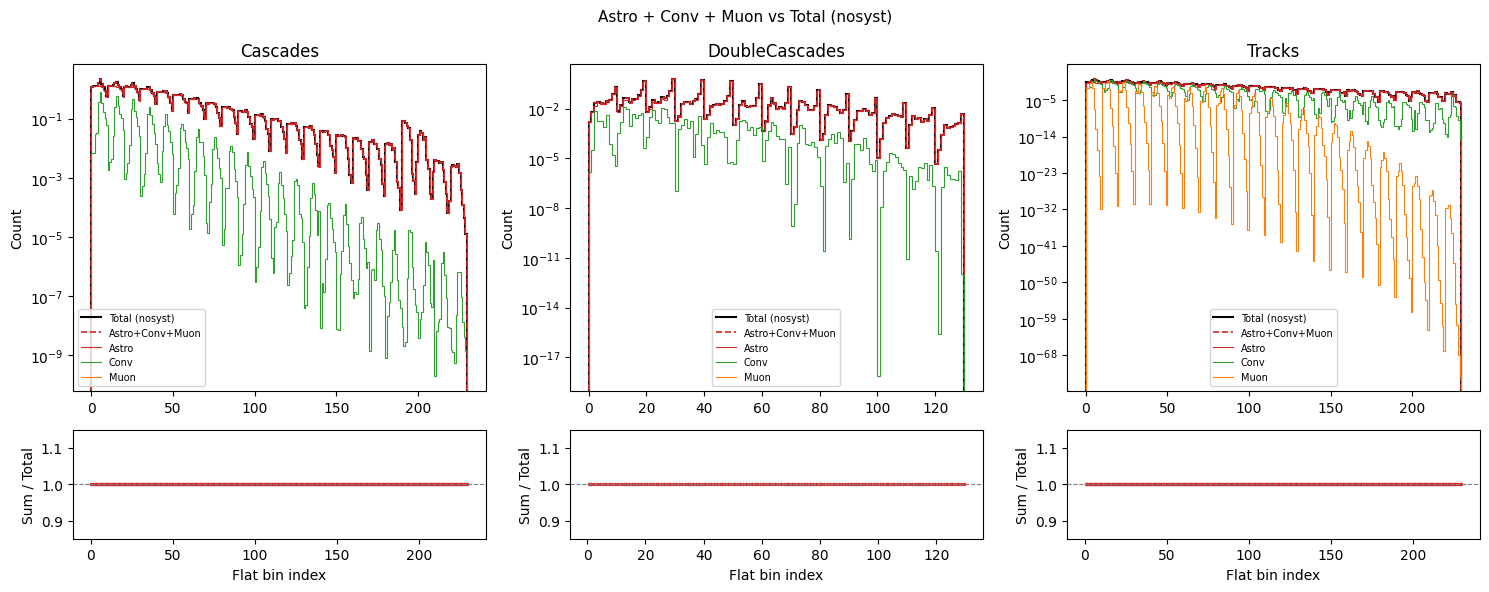

In [17]:
# Build a fake histogram dict for the component sum so ratio_plot can consume it
comp_sum_hists = {
    dc: astro["histograms"][dc] + conv["histograms"][dc] + muon["histograms"][dc]
    for dc in det_configs
}
comp_sum = {"histograms": comp_sum_hists}

ratio_plot(
    "Astro + Conv + Muon vs Total (nosyst)",
    det_configs,
    top_traces=[
        (total["histograms"],    "Total (nosyst)",   "black",      1.5, "-"),
        (comp_sum["histograms"], "Astro+Conv+Muon",  "tab:red",    1.2, "--"),
        (astro["histograms"],    "Astro",             "tab:red",    0.8, "-"),
        (conv["histograms"],     "Conv",              "tab:green",  0.8, "-"),
        (muon["histograms"],     "Muon",              "tab:orange", 0.8, "-"),
    ],
    ratio_traces=[
        (comp_sum["histograms"], total["histograms"], "Sum/Total", "tab:red"),
    ],
    ratio_ylabel="Sum / Total",
)

### 2. Astro (no_flavor model) vs Astro_3flavor (3flavor model)
Same normalization and flavor composition (`total_astro_norm = 3*astro_norm`, `a=0.444`, `b=0`),
but different physics model. Any difference reflects the impact of the 3-flavor parametrization.

IC86_pass2_SnowStorm_FTP_HESE_Cascades | Astro_3flavor / Astro: max |ratio-1| = 6.86e-11
IC86_pass2_SnowStorm_FTP_HESE_DoubleCascades | Astro_3flavor / Astro: max |ratio-1| = 1.00e-10
IC86_pass2_SnowStorm_FTP_HESE_Tracks | Astro_3flavor / Astro: max |ratio-1| = 8.97e-11


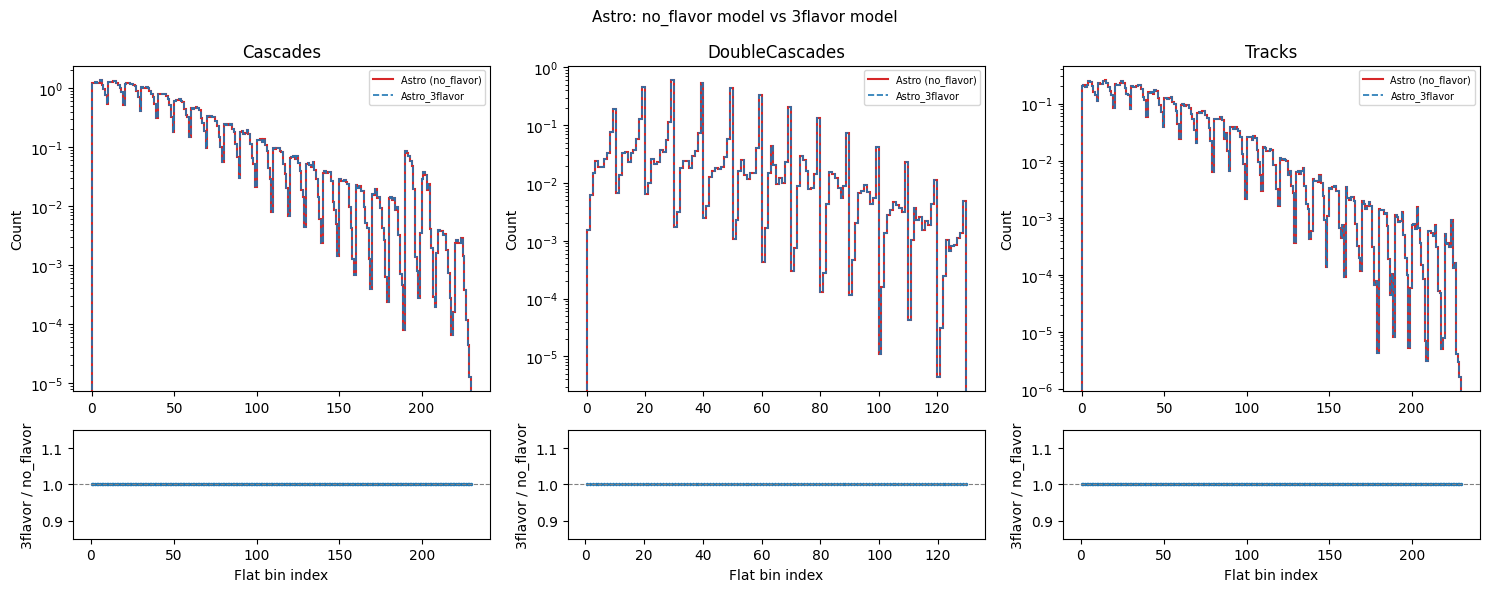

In [18]:
ratio_plot(
    "Astro: no_flavor model vs 3flavor model",
    det_configs,
    top_traces=[
        (astro["histograms"],    "Astro (no_flavor)",  "tab:red",  1.5, "-"),
        (astro_3f["histograms"], "Astro_3flavor",      "tab:blue", 1.2, "--"),
    ],
    ratio_traces=[
        (astro_3f["histograms"], astro["histograms"], "Astro_3flavor / Astro", "tab:blue"),
    ],
    ratio_ylabel="3flavor / no_flavor",
)

### 3. NuE + NuMu + NuTau vs Astro_3flavor
Each flavor component has `total_astro_norm = astro_norm = total_astro_norm/3`,
so their sum should equal `Astro_3flavor` (which has `total_astro_norm = 3*astro_norm`).

IC86_pass2_SnowStorm_FTP_HESE_Cascades | Sum / Astro_3flavor: max |ratio-1| = 6.86e-11
IC86_pass2_SnowStorm_FTP_HESE_DoubleCascades | Sum / Astro_3flavor: max |ratio-1| = 1.00e-10
IC86_pass2_SnowStorm_FTP_HESE_Tracks | Sum / Astro_3flavor: max |ratio-1| = 8.97e-11


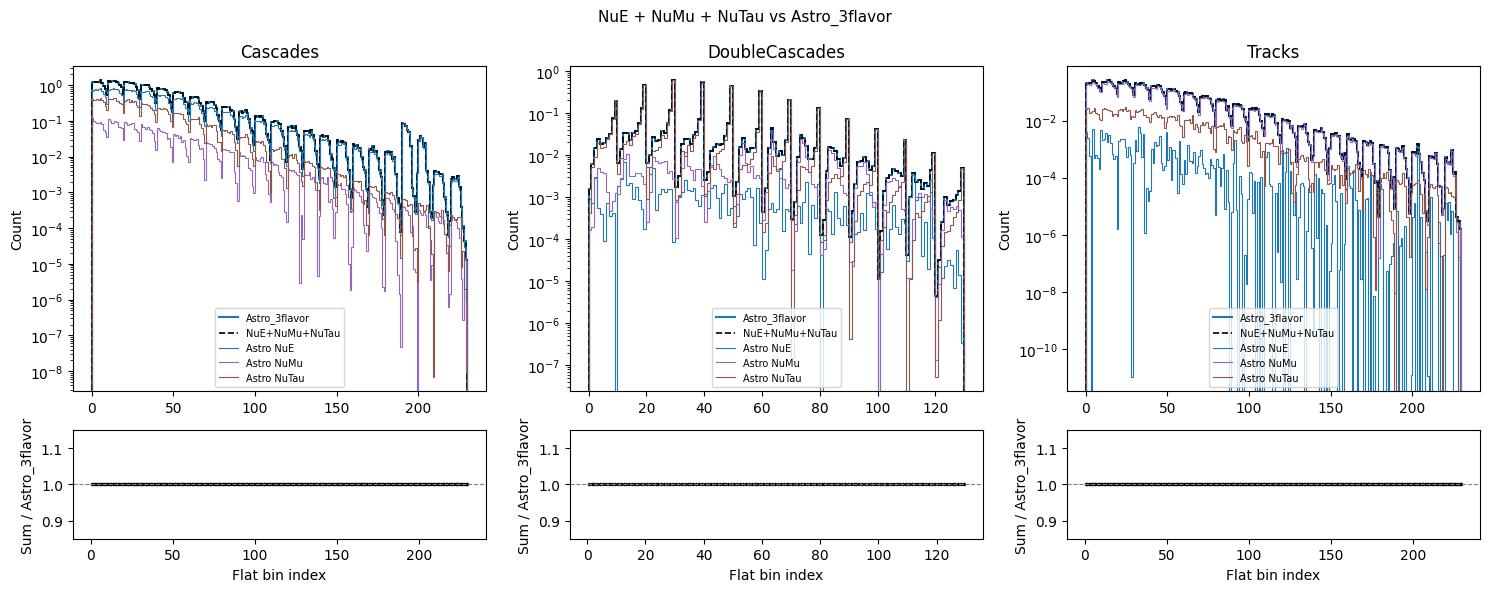

In [19]:
flavor_sum_hists = {
    dc: nue["histograms"][dc] + numu["histograms"][dc] + nutau["histograms"][dc]
    for dc in det_configs
}
flavor_sum = {"histograms": flavor_sum_hists}

ratio_plot(
    "NuE + NuMu + NuTau vs Astro_3flavor",
    det_configs,
    top_traces=[
        (astro_3f["histograms"],    "Astro_3flavor",     "tab:blue",   1.5, "-"),
        (flavor_sum["histograms"],  "NuE+NuMu+NuTau",   "black",      1.2, "--"),
        (nue["histograms"],         "Astro NuE",         "tab:blue",   0.8, "-"),
        (numu["histograms"],        "Astro NuMu",        "tab:purple", 0.8, "-"),
        (nutau["histograms"],       "Astro NuTau",       "tab:brown",  0.8, "-"),
    ],
    ratio_traces=[
        (flavor_sum["histograms"], astro_3f["histograms"], "Sum / Astro_3flavor", "black"),
    ],
    ratio_ylabel="Sum / Astro_3flavor",
)

### 4. Gradient issue: flavor components (nosyst) vs MC total (with syst)

In `plot_functions.py`, `_apply_gradient_to_components` distributes the Snowstorm gradient
only among `COMPONENTS = [Astro, Conv, Muon]`. Flavor components are loaded afterwards as
raw nosyst pickles — they receive **no gradient correction**.

When `plot_flavor=True` the plot shows `MC_syst` as the total line but overlays
`NuE_nosyst + NuMu_nosyst + NuTau_nosyst + Conv_gradient + Muon_nosyst` as components.
These cannot sum to `MC_syst`.

**Step 1** shows the raw discrepancy.
**Step 2** shows the gradient-corrected flavor sum:
- The gradient per bin is `MC_syst - MC_nosyst`.
- The Astro share is `gradient * Astro_nosyst / (Astro_nosyst + Conv_nosyst)`.
- That Astro-gradient is redistributed among NuE/NuMu/NuTau weighted by their nosyst rates.
- Conv gets its usual gradient share; Muon is unchanged.

/tmp/ipykernel_956439/762912775.py:37: RuntimeWarning: divide by zero encountered in divide
  ratio = np.where(syst > 0, current_sum / syst, np.nan)


IC86_pass2_SnowStorm_FTP_HESE_Cascades: max |ratio-1| (current, no gradient on flavors) = 6.20e+00
IC86_pass2_SnowStorm_FTP_HESE_DoubleCascades: max |ratio-1| (current, no gradient on flavors) = 1.92e+01
IC86_pass2_SnowStorm_FTP_HESE_Tracks: max |ratio-1| (current, no gradient on flavors) = 1.63e+02


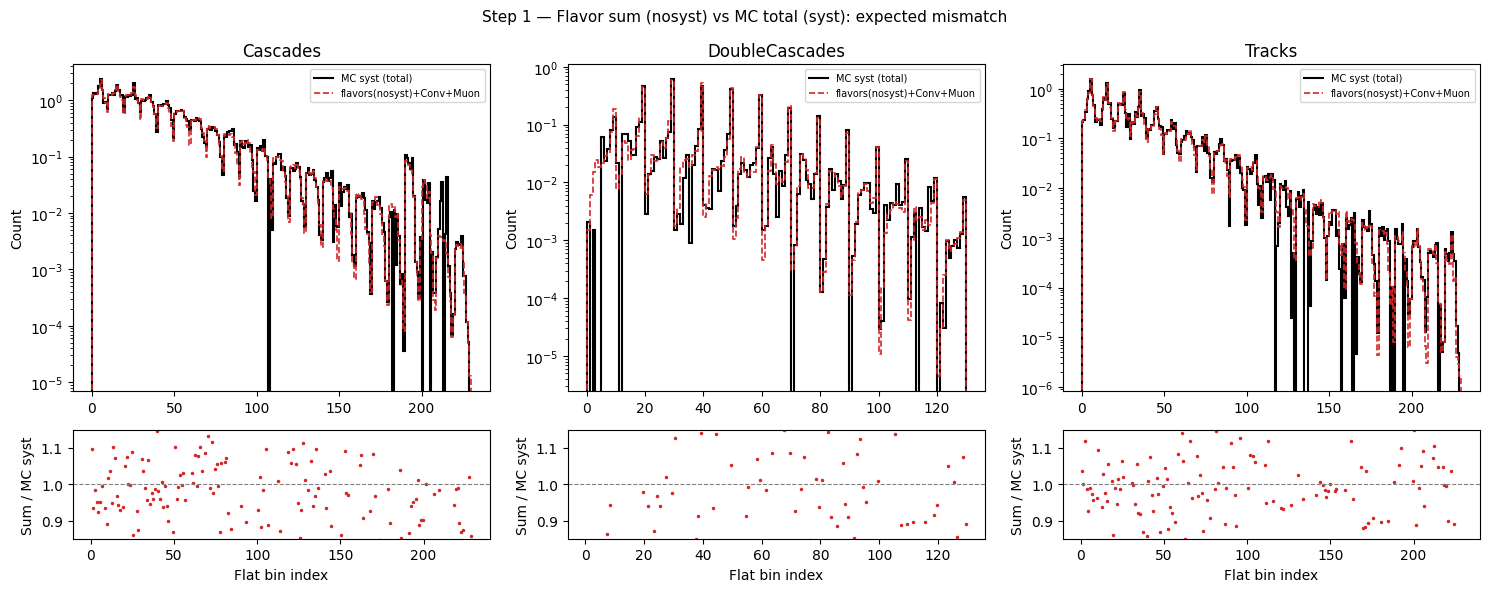

/tmp/ipykernel_956439/762912775.py:89: RuntimeWarning: divide by zero encountered in divide
  ratio = np.where(syst > 0, corrected_sum / syst, np.nan)


IC86_pass2_SnowStorm_FTP_HESE_Cascades: max |ratio-1| (gradient-corrected flavors) = 4.22e-15
IC86_pass2_SnowStorm_FTP_HESE_DoubleCascades: max |ratio-1| (gradient-corrected flavors) = 1.42e-14
IC86_pass2_SnowStorm_FTP_HESE_Tracks: max |ratio-1| (gradient-corrected flavors) = 7.86e-14


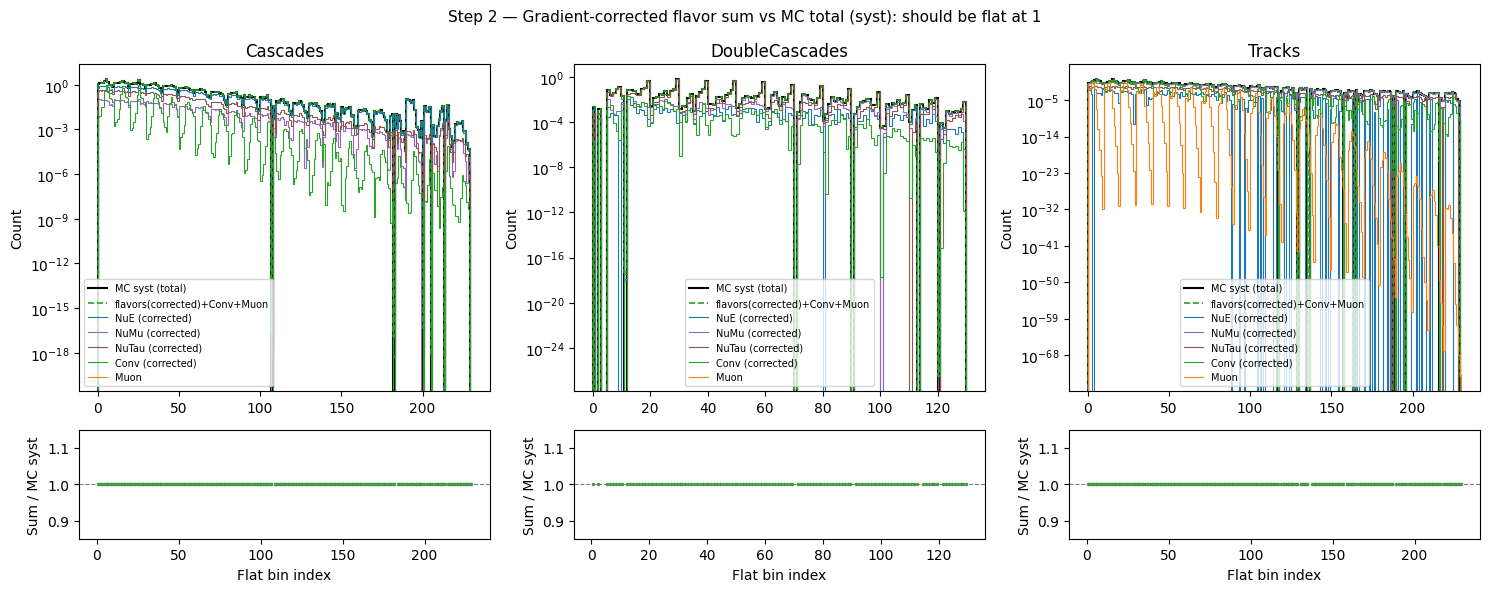

In [20]:
# ---- Step 1: raw nosyst flavor sum vs MC_syst ----
# Conv and Muon as they appear in the flavor plots:
# _apply_gradient_to_components corrects Conv but NOT the flavor components.
# Reproduce that here: Conv gets its gradient share, flavors stay nosyst.

ncols = len(det_configs)
fig, axes = plt.subplots(2, ncols, figsize=(5*ncols, 6),
                          gridspec_kw={"height_ratios": [3, 1]})
if ncols == 1:
    axes = [[axes[0]], [axes[1]]]

for col, dc in enumerate(det_configs):
    syst      = mc_syst["histograms"][dc].ravel()
    nosyst    = total["histograms"][dc].ravel()
    a_ns      = astro["histograms"][dc].ravel()
    c_ns      = conv["histograms"][dc].ravel()
    m_ns      = muon["histograms"][dc].ravel()
    e_ns      = nue["histograms"][dc].ravel()
    mu_ns     = numu["histograms"][dc].ravel()
    tau_ns    = nutau["histograms"][dc].ravel()

    gradient       = syst - nosyst
    non_muon_total = a_ns + c_ns
    conv_corrected = c_ns + np.where(non_muon_total > 0, gradient * c_ns / non_muon_total, 0.0)

    # What the flavor plot currently sums (nosyst flavors + gradient-corrected Conv + nosyst Muon)
    current_sum = e_ns + mu_ns + tau_ns + conv_corrected + m_ns

    bins    = np.arange(len(syst) + 1)
    centers = np.arange(len(syst)) + 0.5
    ax0, ax1 = axes[0][col], axes[1][col]

    ax0.stairs(syst,        bins, label="MC syst (total)",              color="black",      linewidth=1.5)
    ax0.stairs(current_sum, bins, label="flavors(nosyst)+Conv+Muon",    color="tab:red",    linewidth=1.2, linestyle="--")
    ax0.set_yscale("log"); ax0.set_ylabel("Count"); ax0.set_title(dc.split("_")[-1]); ax0.legend(fontsize=7)

    ratio = np.where(syst > 0, current_sum / syst, np.nan)
    ax1.plot(centers, ratio, ".", color="tab:red", markersize=3)
    ax1.axhline(1, color="grey", linestyle="--", linewidth=0.8)
    ax1.set_ylim(0.85, 1.15); ax1.set_ylabel("Sum / MC syst"); ax1.set_xlabel("Flat bin index")
    print(f"{dc}: max |ratio-1| (current, no gradient on flavors) = {np.nanmax(np.abs(ratio-1)):.2e}")

fig.suptitle("Step 1 — Flavor sum (nosyst) vs MC total (syst): expected mismatch", fontsize=11)
plt.tight_layout(); plt.show()

# ---- Step 2: gradient-corrected flavor components ----
fig, axes = plt.subplots(2, ncols, figsize=(5*ncols, 6),
                          gridspec_kw={"height_ratios": [3, 1]})
if ncols == 1:
    axes = [[axes[0]], [axes[1]]]

for col, dc in enumerate(det_configs):
    syst      = mc_syst["histograms"][dc].ravel()
    nosyst    = total["histograms"][dc].ravel()
    a_ns      = astro["histograms"][dc].ravel()
    c_ns      = conv["histograms"][dc].ravel()
    m_ns      = muon["histograms"][dc].ravel()
    e_ns      = nue["histograms"][dc].ravel()
    mu_ns     = numu["histograms"][dc].ravel()
    tau_ns    = nutau["histograms"][dc].ravel()

    gradient        = syst - nosyst
    non_muon_total  = a_ns + c_ns

    # Astro's share of the gradient, then redistributed among the 3 flavor components
    astro_grad      = np.where(non_muon_total > 0, gradient * a_ns / non_muon_total, 0.0)
    flavor_total_ns = e_ns + mu_ns + tau_ns
    nue_c   = e_ns   + np.where(flavor_total_ns > 0, astro_grad * e_ns   / flavor_total_ns, 0.0)
    numu_c  = mu_ns  + np.where(flavor_total_ns > 0, astro_grad * mu_ns  / flavor_total_ns, 0.0)
    nutau_c = tau_ns + np.where(flavor_total_ns > 0, astro_grad * tau_ns / flavor_total_ns, 0.0)
    conv_c  = c_ns   + np.where(non_muon_total  > 0, gradient   * c_ns   / non_muon_total,  0.0)
    # Muon unchanged (gradient doesn't affect muon)

    corrected_sum = nue_c + numu_c + nutau_c + conv_c + m_ns

    bins    = np.arange(len(syst) + 1)
    centers = np.arange(len(syst)) + 0.5
    ax0, ax1 = axes[0][col], axes[1][col]

    ax0.stairs(syst,          bins, label="MC syst (total)",             color="black",      linewidth=1.5)
    ax0.stairs(corrected_sum, bins, label="flavors(corrected)+Conv+Muon",color="tab:green",  linewidth=1.2, linestyle="--")
    ax0.stairs(nue_c,   bins, label="NuE (corrected)",  color="tab:blue",   linewidth=0.8)
    ax0.stairs(numu_c,  bins, label="NuMu (corrected)", color="tab:purple", linewidth=0.8)
    ax0.stairs(nutau_c, bins, label="NuTau (corrected)",color="tab:brown",  linewidth=0.8)
    ax0.stairs(conv_c,  bins, label="Conv (corrected)", color="tab:green",  linewidth=0.8)
    ax0.stairs(m_ns,    bins, label="Muon",              color="tab:orange", linewidth=0.8)
    ax0.set_yscale("log"); ax0.set_ylabel("Count"); ax0.set_title(dc.split("_")[-1]); ax0.legend(fontsize=7)

    ratio = np.where(syst > 0, corrected_sum / syst, np.nan)
    ax1.plot(centers, ratio, ".", color="tab:green", markersize=3)
    ax1.axhline(1, color="grey", linestyle="--", linewidth=0.8)
    ax1.set_ylim(0.85, 1.15); ax1.set_ylabel("Sum / MC syst"); ax1.set_xlabel("Flat bin index")
    print(f"{dc}: max |ratio-1| (gradient-corrected flavors) = {np.nanmax(np.abs(ratio-1)):.2e}")

fig.suptitle("Step 2 — Gradient-corrected flavor sum vs MC total (syst): should be flat at 1", fontsize=11)
plt.tight_layout(); plt.show()